1. Notebook Structure

In [1]:
# Cell 1: Environment Setup
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import wfdb

# Add the parent directory to sys.path so we can import 'src'
sys.path.append(os.path.abspath('..'))
from src import ECGDetectors, NoiseGenerator, Evaluator

# Visualization settings
plt.style.use('seaborn-v0_8-muted')
%matplotlib inline

2. Signal Visualization

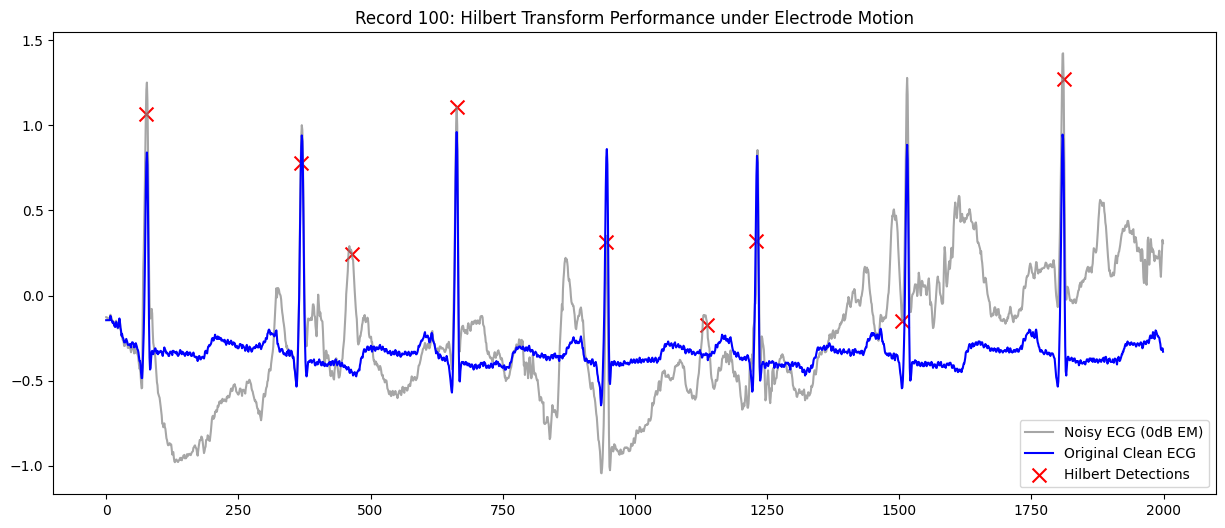

In [5]:
# Cell 2: Visualizing Noise Injection
rec_id = '100'
record = wfdb.rdrecord(f'c:/Users/Divine/Desktop/Stress_Test Project/ECG-Algorithm-Benchmark/data/mitbih/{rec_id}', channels=[0])
clean_sig = record.p_signal.flatten()[:2000] # First 2000 samples

# Load EM Noise
noise_rec = wfdb.rdrecord('c:/Users/Divine/Desktop/Stress_Test Project/ECG-Algorithm-Benchmark/data/nstdb/em', channels=[0])
raw_noise = noise_rec.p_signal.flatten()

# Generate Noisy Signal at 0dB
noisy_sig = NoiseGenerator.apply_noise(clean_sig, raw_noise, target_snr=0)

# Detect using Hilbert
peaks = ECGDetectors.hilbert_transform(noisy_sig, fs=360)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(noisy_sig, label='Noisy ECG (0dB EM)', alpha=0.7, color='gray')
plt.plot(clean_sig, label='Original Clean ECG', color='blue', linewidth=1.5)
plt.scatter(peaks, noisy_sig[peaks], color='red', marker='x', s=100, label='Hilbert Detections')
plt.title(f"Record {rec_id}: Hilbert Transform Performance under Electrode Motion")
plt.legend()
plt.show()

3. Plotting the Stress Test Results

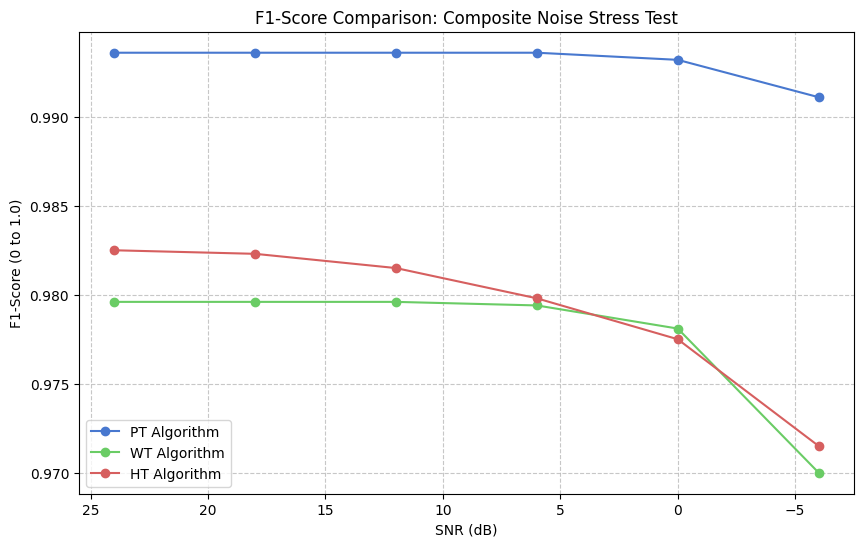

In [10]:
# Cell 3: Comparative F1-Score Plot
results_df = pd.read_csv('c:/Users/Divine/Desktop/Stress_Test Project/ECG-Algorithm-Benchmark/results/bw_results.csv')

plt.figure(figsize=(10, 6))
for alg in ['PT', 'WT', 'HT']:
    data = results_df[results_df['Algorithm'] == alg]
    plt.plot(data['SNR'], data['F1_Score'], marker='o', label=f'{alg} Algorithm')

plt.gca().invert_xaxis() # High SNR to Low SNR
plt.title("F1-Score Comparison: Composite Noise Stress Test")
plt.xlabel("SNR (dB)")
plt.ylabel("F1-Score (0 to 1.0)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

4. Creating the "Summary Table"

In [11]:
# Cell 4: Summary of Failure Points
summary = results_df[results_df['SNR'] == -6].copy()
summary = summary[['Algorithm', 'Sensitivity', 'Precision', 'F1_Score', 'Error_Rate']]
summary.sort_values(by='F1_Score', ascending=False, inplace=True)

print("--- Performance Breakdown at -6dB (Extreme Noise) ---")
display(summary)

--- Performance Breakdown at -6dB (Extreme Noise) ---


,Algorithm,Sensitivity,Precision,F1_Score,Error_Rate
15,PT,98.95,99.27,0.9911,1.78
17,HT,99.82,94.63,0.9715,5.85
16,WT,96.46,97.55,0.9700,5.96
